# Milestone 1 — Data Report & EDA
## Real-Time Retail Feedback Intelligence — *ChicStyle*

**Business context.** ChicStyle, a growing fashion retailer, is flooded with customer reviews
during festive sales. Slow reaction to negative/urgent feedback hurts trust and revenue. The
capstone goal (later milestones) is a **Generative-AI** system using prompt engineering
(Zero-Shot, Few-Shot, Chain-of-Thought) to detect sentiment, identify the product/aspect,
flag urgent issues, **estimate the product rating**, and auto-respond to customers.

**Dataset — *Women's E-Commerce Clothing Reviews*.** Each row is one customer review.

| Column | Meaning |
|---|---|
| `Clothing.ID` | Unique product identifier |
| `Age` | Reviewer age |
| `Title` | Review title |
| `Review.Text` | Full review body |
| `Rating` | Star rating 1 (worst) – 5 (best) — **target variable** |
| `Recommended.IND` | 1 = recommends, 0 = does not |
| `Positive.Feedback.Count` | # other customers who found the review helpful |
| `Division.Name` | High-level product division |
| `Department.Name` | Product department |
| `Class.Name` | Specific product class |


## Setup — Imports & Configuration

In [1]:
# Core data-analysis and visualization libraries
import pandas as pd                 # dataframes / IO
import numpy as np                  # numeric operations
import matplotlib.pyplot as plt     # base plotting
import seaborn as sns               # statistical visualizations

# Section 1 — Data Description & Understanding

### 1.1 Detailed description of the data (rows, columns, etc.)

In [2]:
# Load the dataset. NOTE: the file is SEMICOLON-separated and its first unnamed
# column is just a row index, so we pass sep=';' and index_col=0.
df = pd.read_csv('Dataset Real-Time Retail Feedback Intelligence.csv', sep=';', index_col=0)

In [3]:
#Printing top 5 rows
df.head()

,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
1,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
2,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [4]:
#Printing last 5 rows
df.tail()

,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
23482,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23483,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23484,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23485,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses
23486,1104,52,Please make more like this one!,This dress in a lovely platinum is feminine an...,5,1,22,General Petite,Dresses,Dresses


In [5]:
# High-level size description of the dataset
print(f'Number of rows (records) : {df.shape[0]:,}')
print(f'Number of columns        : {df.shape[1]}')
print(f'Column names             : {list(df.columns)}')

Number of rows (records) : 23,486
Number of columns        : 10
Column names             : ['Clothing.ID', 'Age', 'Title', 'Review.Text', 'Rating', 'Recommended.IND', 'Positive.Feedback.Count', 'Division.Name', 'Department.Name', 'Class.Name']


### 1.2 Descriptive statistics of the data

In [6]:
# df.info() -> dtype and non-null count for every column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 1 to 23486
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing.ID              23486 non-null  int64
 1   Age                      23486 non-null  int64
 2   Title                    19676 non-null  str  
 3   Review.Text              22641 non-null  str  
 4   Rating                   23486 non-null  int64
 5   Recommended.IND          23486 non-null  int64
 6   Positive.Feedback.Count  23486 non-null  int64
 7   Division.Name            23472 non-null  str  
 8   Department.Name          23472 non-null  str  
 9   Class.Name               23472 non-null  str  
dtypes: int64(5), str(5)
memory usage: 1.8 MB


In [7]:
# Statistical summary of NUMERIC columns (count, mean, std, min, quartiles, max)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Clothing.ID,23486.0,918.118709,203.298980,0.0,861.0,936.0,1078.0,1205.0
Age,23486.0,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Rating,23486.0,4.196032,1.110031,1.0,4.0,5.0,5.0,5.0
Recommended.IND,23486.0,0.822362,0.382216,0.0,1.0,1.0,1.0,1.0
Positive.Feedback.Count,23486.0,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0


In [8]:
# Statistical summary of NON-NUMERIC/text columns (count, unique, top value, frequency)
df.describe(include=['object', 'string']).T

,count,unique,top,freq
Title,19676,13993,Love it!,136
Review.Text,22641,22634,Perfect fit and i've gotten so many compliment...,3
Division.Name,23472,3,General,13850
Department.Name,23472,6,Tops,10468
Class.Name,23472,20,Dresses,6319


### 1.3 Variable types & attributes; rename if required

In [9]:
# Classify each variable by its true statistical type (not just pandas dtype).
# This informs which plots/tests are appropriate later.
var_types = pd.DataFrame({
    'column': df.columns,
    'pandas_dtype': [str(t) for t in df.dtypes],
    'variable_type': [
        'Nominal / Identifier',   # Clothing.ID  - label, not a quantity
        'Continuous (discrete)',  # Age
        'Text (nominal)',         # Title
        'Text (nominal)',         # Review.Text
        'Ordinal',                # Rating 1..5 has natural order
        'Binary / Nominal',       # Recommended.IND
        'Continuous (discrete)',  # Positive.Feedback.Count
        'Nominal (categorical)',  # Division.Name
        'Nominal (categorical)',  # Department.Name
        'Nominal (categorical)',  # Class.Name
    ],
    'unique_values': df.nunique().values,
})
var_types

,column,pandas_dtype,variable_type,unique_values
0,Clothing.ID,int64,Nominal / Identifier,1206
1,Age,int64,Continuous (discrete),77
2,Title,str,Text (nominal),13993
3,Review.Text,str,Text (nominal),22634
4,Rating,int64,Ordinal,5
5,Recommended.IND,int64,Binary / Nominal,2
6,Positive.Feedback.Count,int64,Continuous (discrete),82
7,Division.Name,str,Nominal (categorical),3
8,Department.Name,str,Nominal (categorical),6
9,Class.Name,str,Nominal (categorical),20


In [10]:
# Rename dotted CamelCase columns to clean, consistent snake_case for easier reference.
rename_map = {
    'Clothing.ID': 'clothing_id',   'Age': 'age',
    'Title': 'title',               'Review.Text': 'review_text',
    'Rating': 'rating',             'Recommended.IND': 'recommended_ind',
    'Positive.Feedback.Count': 'positive_feedback_count',
    'Division.Name': 'division_name', 'Department.Name': 'department_name',
    'Class.Name': 'class_name',
}
df = df.rename(columns=rename_map)   # apply the rename
print('Renamed columns:', list(df.columns))

Renamed columns: ['clothing_id', 'age', 'title', 'review_text', 'rating', 'recommended_ind', 'positive_feedback_count', 'division_name', 'department_name', 'class_name']


### 1.4 Inference on the data

- The dataset holds 23,486 reviews across 10 attributes
- The target for the business objective is "rating" (1–5); "recommended_ind" is a closely related binary signal.
- Real predictive signal lives in the "free-text" fields (review_text, title); the structured
  columns mainly provide product context (division / department / class) and reviewer context (age).
- title and review_text already show missing values (visible in info())


# Section 2 — Initial Analysis (EDA)

### 2.1 Univariate analysis — distribution & spread of every continuous attribute

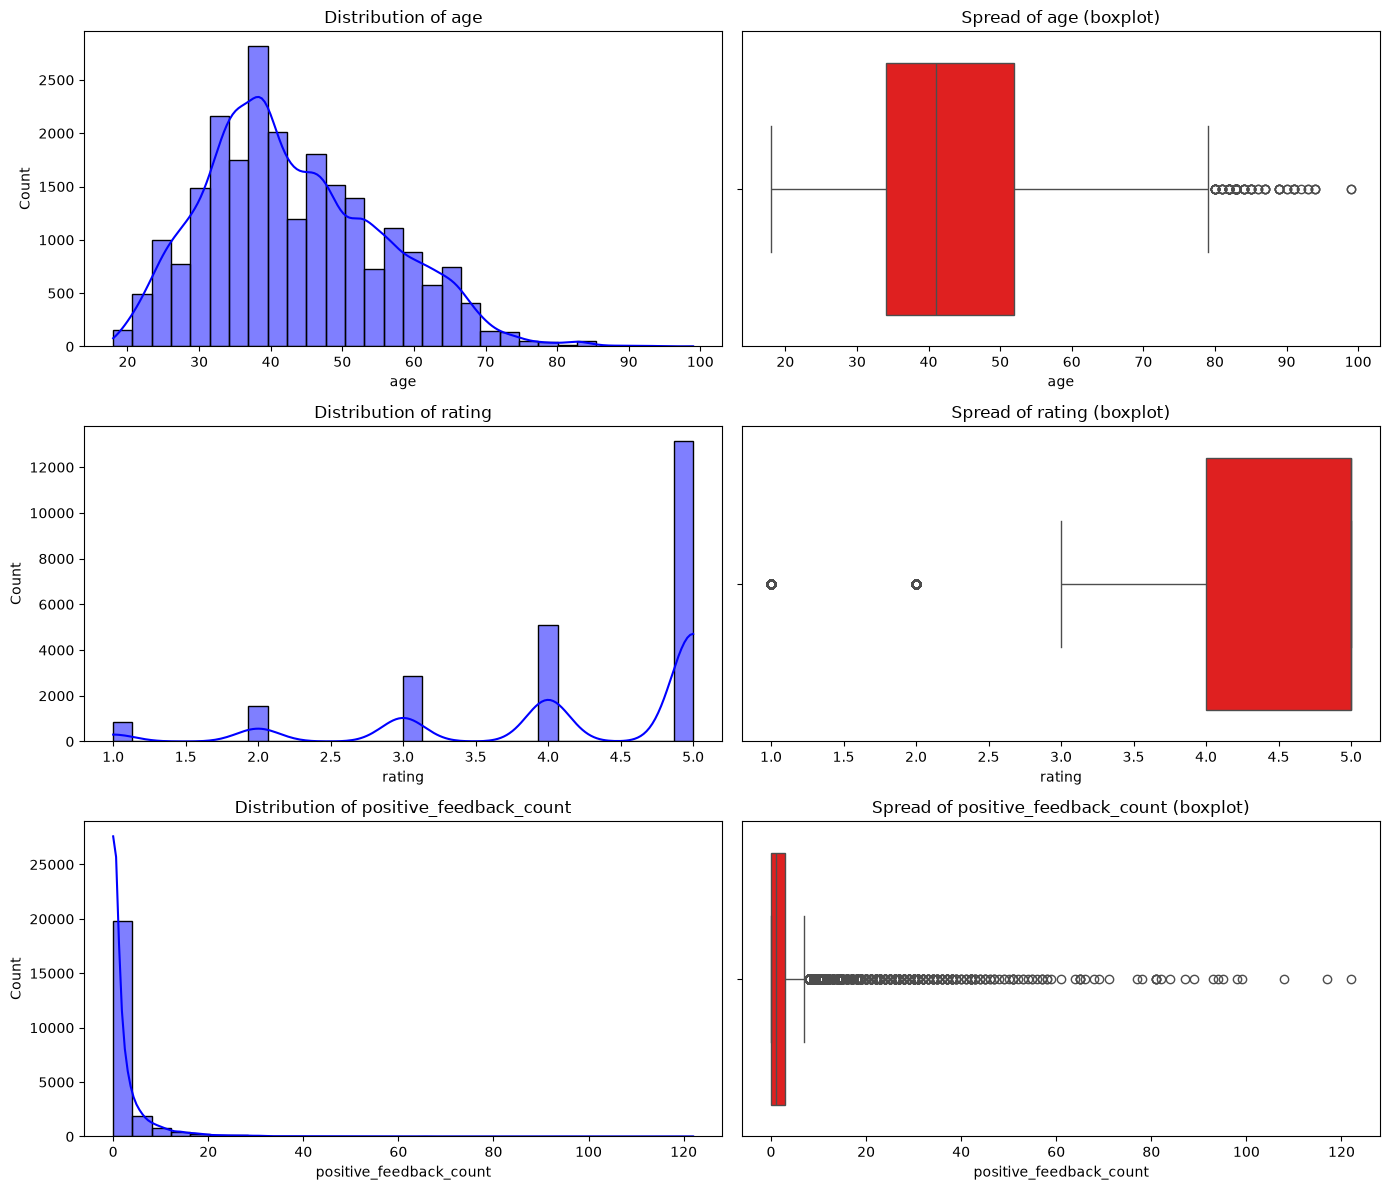

,count,mean,std,min,25%,50%,75%,max,IQR,skewness,kurtosis
age,23486.0,43.20,12.28,18.0,34.0,41.0,52.0,99.0,18.0,0.53,-0.11
rating,23486.0,4.20,1.11,1.0,4.0,5.0,5.0,5.0,1.0,-1.31,0.80
positive_feedback_count,23486.0,2.54,5.70,0.0,0.0,1.0,3.0,122.0,3.0,6.47,71.69


In [11]:
# Continuous attributes to profile univariately
continuous_cols = ['age', 'rating', 'positive_feedback_count']

# For each: histogram+KDE (distribution) on the left, boxplot (spread) on the right
fig, axes = plt.subplots(len(continuous_cols), 2, figsize=(14, 4*len(continuous_cols)))
for i, col in enumerate(continuous_cols):
    sns.histplot(df[col], kde=True, bins=30, color='blue', ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribution of {col}')
    sns.boxplot(x=df[col], color='red', ax=axes[i, 1])
    axes[i, 1].set_title(f'Spread of {col} (boxplot)')
plt.tight_layout(); plt.show()

# Numeric distribution & spread statistics (incl. IQR, skew, kurtosis)
stats = df[continuous_cols].describe().T
stats['IQR']      = stats['75%'] - stats['25%']          # inter-quartile range (spread)
stats['skewness'] = df[continuous_cols].skew()           # asymmetry of distribution
stats['kurtosis'] = df[continuous_cols].kurtosis()       # tailedness
display(stats.round(2))

### 2.2 Distribution of data across categories (categorical attributes)

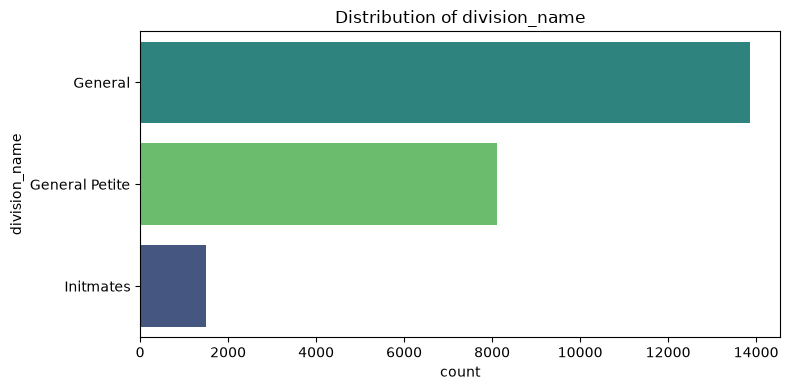

--- division_name (%) ---
division_name
General           59.01
General Petite    34.59
Initmates          6.40 



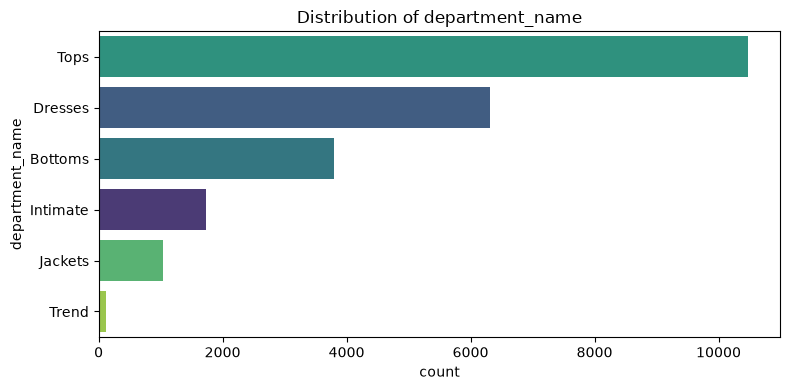

--- department_name (%) ---
department_name
Tops        44.60
Dresses     26.92
Bottoms     16.19
Intimate     7.39
Jackets      4.40
Trend        0.51 



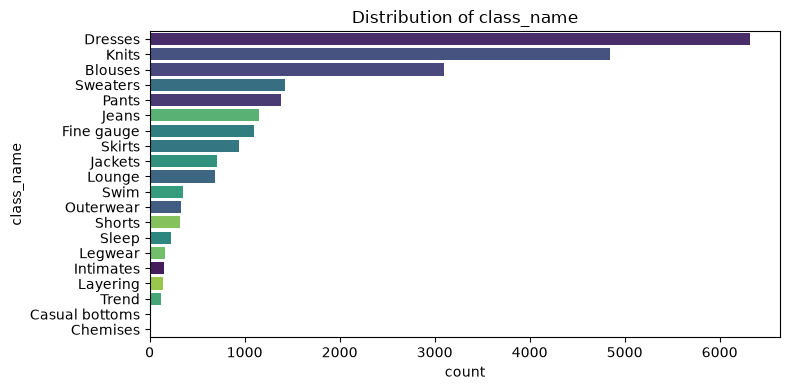

--- class_name (%) ---
class_name
Dresses           26.92
Knits             20.63
Blouses           13.19
Sweaters           6.08
Pants              5.91
Jeans              4.89
Fine gauge         4.69
Skirts             4.03
Jackets            3.00
Lounge             2.94
Swim               1.49
Outerwear          1.40
Shorts             1.35
Sleep              0.97
Legwear            0.70
Intimates          0.66
Layering           0.62
Trend              0.51
Casual bottoms     0.01
Chemises           0.00 



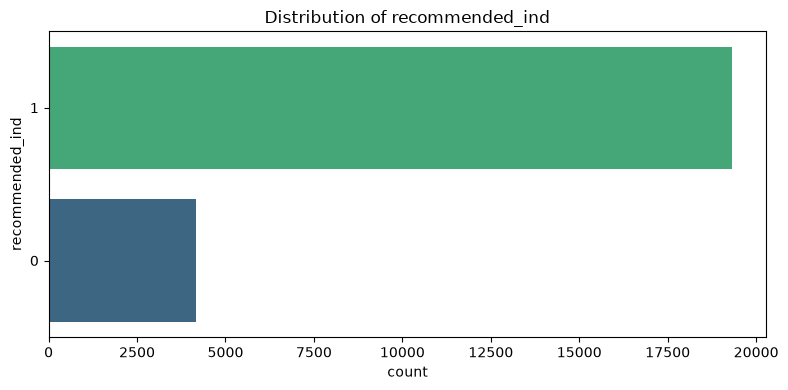

--- recommended_ind (%) ---
recommended_ind
1    82.24
0    17.76 



In [12]:
# Categorical attributes (recommended_ind is a binary category)
cat_cols = ['division_name', 'department_name', 'class_name', 'recommended_ind']

# Plot each categorical attribute in its own separate graph
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index,
                  hue=col, palette='viridis', legend=False)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

    # Print the percentage share of each category
    print(f'--- {col} (%) ---')
    print((df[col].value_counts(normalize=True) * 100).round(2).to_string(), '\n')

### 2.3 Bivariate analysis for important variables

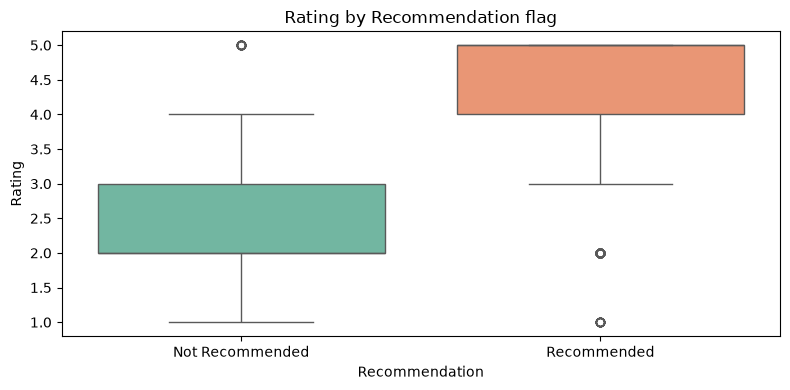

In [13]:
# (a) rating vs recommendation flag -> do higher ratings drive recommendations?
plt.figure(figsize=(8, 4))
sns.boxplot(x='recommended_ind', y='rating', data=df, hue='recommended_ind',
            palette='Set2', legend=False)
plt.title('Rating by Recommendation flag')          
plt.xlabel('Recommendation')                         
plt.ylabel('Rating')                                 
plt.xticks([0, 1], ['Not Recommended', 'Recommended'])  
plt.tight_layout()
plt.show()


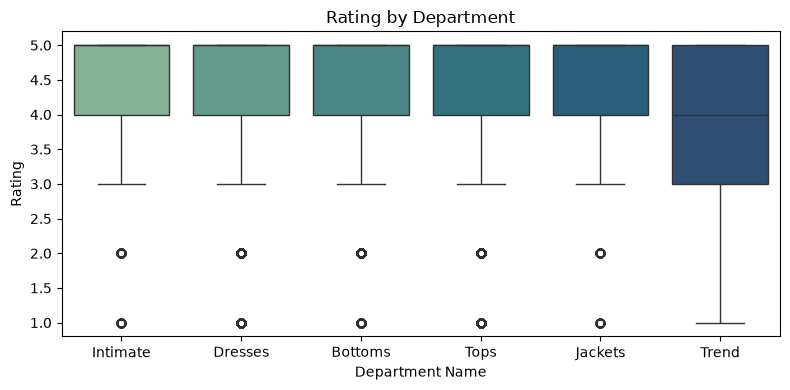

In [14]:

# (b) rating spread across departments -> which departments underperform?
plt.figure(figsize=(8, 4))
sns.boxplot(x='department_name', y='rating', data=df, hue='department_name',
            palette='crest', legend=False)

plt.title('Rating by Department')          
plt.xlabel('Department Name')                         
plt.ylabel('Rating')                                 
plt.tight_layout();
plt.show()


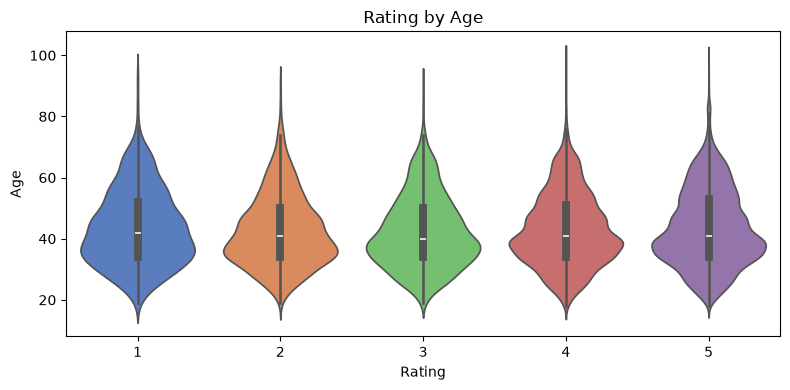

In [15]:
# (c) age distribution per rating -> is dissatisfaction age-related?
plt.figure(figsize=(8, 4))
sns.violinplot(x='rating', y='age', data=df, hue='rating',
               palette='muted', legend=False)

plt.title('Rating by Age')          
plt.xlabel('Rating')                         
plt.ylabel('Age') 
plt.tight_layout();
plt.show()


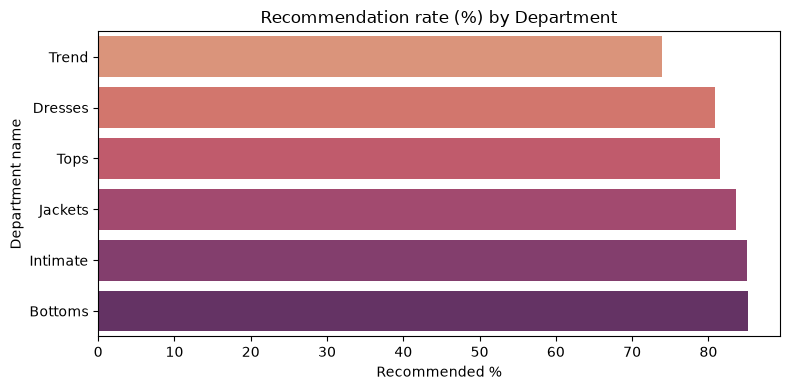

Mean rating by recommendation flag:
recommended_ind
0    2.3
1    4.6
Name: rating, dtype: float64


In [16]:
# (d) recommendation rate by department -> category-level satisfaction
plt.figure(figsize=(8, 4))
rec_rate = df.groupby('department_name')['recommended_ind'].mean().sort_values()*100
sns.barplot(x=rec_rate.values, y=rec_rate.index, hue=rec_rate.index,
            palette='flare', legend=False)

plt.title('Recommendation rate (%) by Department')          
plt.xlabel('Recommended %')                         
plt.ylabel('Department name') 

plt.tight_layout();
plt.show()

# Supporting numbers
print('Mean rating by recommendation flag:')
print(df.groupby('recommended_ind')['rating'].mean().round(2))

### 2.4 Relationships between variables and their correlations

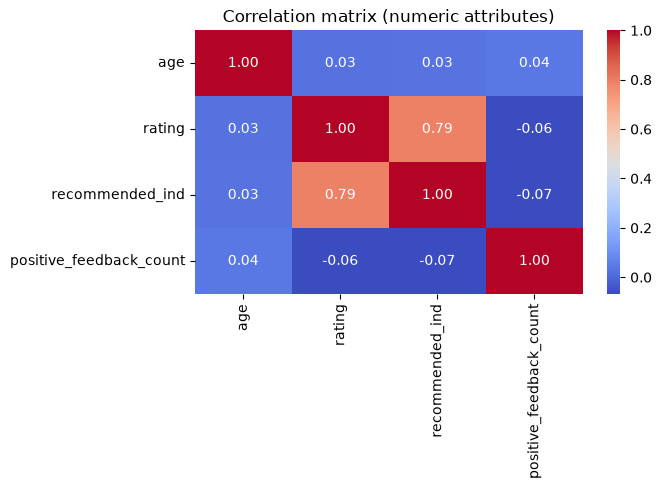

In [17]:
# Pearson correlation among numeric attributes
num_cols = ['age', 'rating', 'recommended_ind', 'positive_feedback_count']
corr = df[num_cols].corr()

# Heatmap of the correlation matrix
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix (numeric attributes)');
plt.tight_layout()
plt.show()



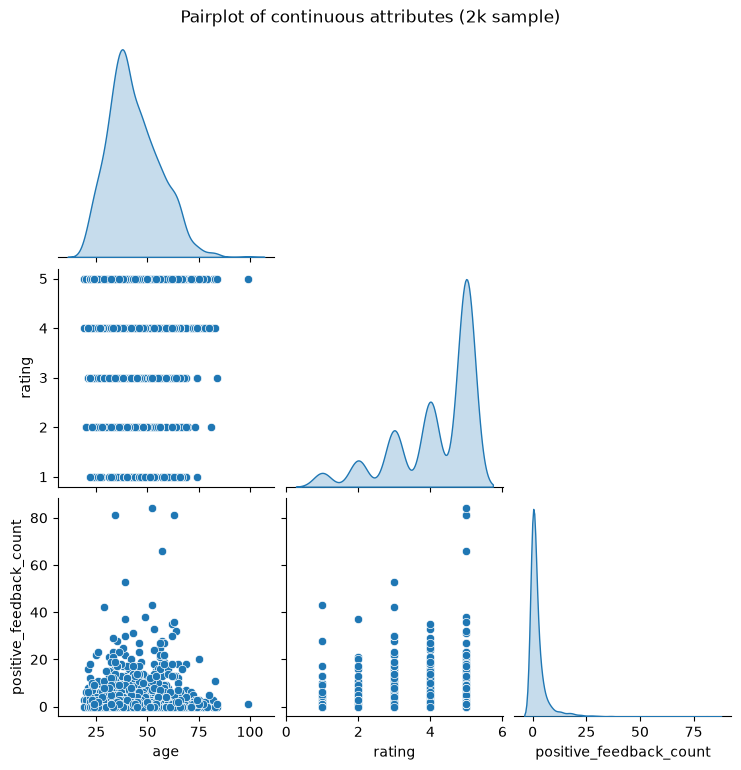

,age,rating,recommended_ind,positive_feedback_count
age,1.000,0.027,0.031,0.043
rating,0.027,1.000,0.792,-0.065
recommended_ind,0.031,0.792,1.000,-0.069
positive_feedback_count,0.043,-0.065,-0.069,1.000


In [18]:
# Pairplot on a sample to inspect joint relationships of continuous variables
sns.pairplot(df[['age', 'rating', 'positive_feedback_count']].sample(2000, random_state=42),
             diag_kind='kde', corner=True)
plt.suptitle('Pairplot of continuous attributes (2k sample)', y=1.02); plt.show()

corr.round(3)

### 2.5 Data insights & summarization

In [19]:
# Compute headline metrics that summarise the dataset
print('KEY QUANTITATIVE INSIGHTS')
print('=' * 45)
print(f"Total reviews                 : {len(df):,}")
print(f"Mean rating                   : {df['rating'].mean():.2f} / 5")
print(f"% of 4-5 star reviews         : {(df['rating']>=4).mean()*100:.1f}%")
print(f"% recommended                 : {df['recommended_ind'].mean()*100:.1f}%")
print(f"Median reviewer age           : {df['age'].median():.0f} years")
print(f"Most-reviewed department      : {df['department_name'].value_counts().idxmax()}")
print(f"Lowest avg-rating department  : {df.groupby('department_name')['rating'].mean().idxmin()}")
print(f"Corr(rating, recommended_ind) : {df['rating'].corr(df['recommended_ind']):.2f}")

KEY QUANTITATIVE INSIGHTS
Total reviews                 : 23,486
Mean rating                   : 4.20 / 5
% of 4-5 star reviews         : 77.5%
% recommended                 : 82.2%
Median reviewer age           : 41 years
Most-reviewed department      : Tops
Lowest avg-rating department  : Trend
Corr(rating, recommended_ind) : 0.79


**Section 2 insights**

1. **Ratings skew positive** (strongly left-skewed) — 4–5 stars dominate, so negative reviews are a
   *minority but high-value*.
2. **Rating ↔ recommendation are tightly linked** — a low predicted rating is a reliable metrics for
   "would not recommend".
3. **`positive_feedback_count` is highly right-skewed** — most reviews get few helpful votes; a few
   go viral and deserve priority attention.
4. **Volume is concentrated** in *Tops* and *Dresses* — insights and response staffing should be
   weighted by department.
5. **Age barely correlates with rating** — dissatisfaction is not demographic-driven.


# Section 3 — Data Preprocessing

### 3.1 Remove unnecessary variables for model building (w.r.t. the target)
**Target variable = `rating`** (the objective is to *estimate the product rating*). We assess each
feature's usefulness for modelling and drop only what adds no predictive value.

In [20]:
# Remove exact duplicate records first (they bias any analysis/model)
dups = df.duplicated().sum()
print(f'Exact duplicate rows found: {dups}')
df = df.drop_duplicates().reset_index(drop=True)


Exact duplicate rows found: 21


In [21]:
# clothing_id is a pure IDENTIFIER (23k+ unique labels) -> no predictive signal w.r.t. rating.
# All other columns are kept: text = model input, division/department/class = context,
# age/positive_feedback_count = supporting features, recommended_ind = related label.
df = df.drop(columns=['clothing_id'])
print('Dropped: clothing_id (identifier, not predictive).')
print('Remaining columns:', list(df.columns))

Dropped: clothing_id (identifier, not predictive).
Remaining columns: ['age', 'title', 'review_text', 'rating', 'recommended_ind', 'positive_feedback_count', 'division_name', 'department_name', 'class_name']


### 3.2 Identify & treat missing values

In [22]:
# Identify: count and % of missing values per column
missing = pd.DataFrame({'missing': df.isnull().sum()})
missing

,missing
age,0
title,3789
review_text,825
rating,0
recommended_ind,0
positive_feedback_count,0
division_name,14
department_name,14
class_name,14


In [23]:
# Treat (conservative strategy):
before = len(df)
# review_text is the CORE signal -> rows without it are unusable, so drop them
df = df.dropna(subset=['review_text']).reset_index(drop=True)
print(f'Dropped {before-len(df)} rows with empty review_text.')

Dropped 825 rows with empty review_text.


In [24]:
# title is optional -> fill missing with empty string
df['title'] = df['title'].fillna('')
# product-context categories: only a handful missing & co-occur -> label 'Unknown'
for col in ['division_name', 'department_name', 'class_name']:
    df[col] = df[col].fillna('Unknown')

print('Remaining missing values:', int(df.isnull().sum().sum()))

Remaining missing values: 0


### 3.3 Identify & treat outliers

In [25]:
# Use the IQR rule to flag outliers on the truly continuous columns.
def iqr_bounds(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr           # lower, upper fences

for col in ['age', 'positive_feedback_count']:
    lo, hi = iqr_bounds(df[col])
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'{col}: IQR fences=({lo:.1f}, {hi:.1f}) -> {n_out} outliers ({n_out/len(df)*100:.2f}%)')

# Treatment: CAP (winsorize) age at its IQR fences so extreme ages don't distort stats.
lo, hi = iqr_bounds(df['age'])
df['age'] = df['age'].clip(lower=lo, upper=hi)

age: IQR fences=(7.0, 79.0) -> 108 outliers (0.48%)
positive_feedback_count: IQR fences=(-4.5, 7.5) -> 2147 outliers (9.48%)


### 3.4 Transform variables & add new variables

In [26]:
# (a) NEW: sentiment label derived from the target rating (used heavily in later milestones)
def rating_to_sentiment(r):
    if r <= 2:   return 'Negative'
    elif r == 3: return 'Neutral'
    else:        return 'Positive'
df['sentiment'] = df['rating'].apply(rating_to_sentiment)
df.head()


,age,title,review_text,rating,recommended_ind,positive_feedback_count,division_name,department_name,class_name,sentiment
0,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,Positive
1,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,Positive
2,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Neutral
3,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,Positive
4,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,Positive


In [27]:
# (b) NEW: review_length = word count of the review (a useful engagement/effort signal)
df['review_length'] = df['review_text'].str.split().str.len()
df.head()


,age,title,review_text,rating,recommended_ind,positive_feedback_count,division_name,department_name,class_name,sentiment,review_length
0,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,Positive,8
1,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,Positive,62
2,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Neutral,98
3,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,Positive,22
4,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,Positive,36


In [28]:
# (c) TRANSFORM: log1p of the highly-skewed feedback count to normalise its distribution
df['log_positive_feedback'] = np.log1p(df['positive_feedback_count'])
df.head()


,age,title,review_text,rating,recommended_ind,positive_feedback_count,division_name,department_name,class_name,sentiment,review_length,log_positive_feedback
0,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,Positive,8,0.000000
1,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,Positive,62,1.609438
2,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Neutral,98,0.000000
3,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,Positive,22,0.000000
4,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,Positive,36,1.945910


In [29]:
# (d) NEW: age_group buckets for readable demographic breakdowns
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 120],
                         labels=['<=25', '26-35', '36-45', '46-55', '55+'])

print('Added columns: sentiment, review_length, log_positive_feedback, age_group')
display(df[['rating', 'sentiment', 'review_length',
            'positive_feedback_count', 'log_positive_feedback', 'age', 'age_group']].head())

Added columns: sentiment, review_length, log_positive_feedback, age_group


,rating,sentiment,review_length,positive_feedback_count,log_positive_feedback,age,age_group
0,4,Positive,8,0,0.000000,33,26-35
1,5,Positive,62,4,1.609438,34,26-35
2,3,Neutral,98,0,0.000000,60,55+
3,5,Positive,22,0,0.000000,50,46-55
4,5,Positive,36,6,1.945910,47,46-55


### 3.5 Justification & summary of preprocessing

| Step | Action | Justification |
|---|---|---|
| Duplicates | Dropped **21** exact duplicates | Repeated rows bias distributions and any model. |
| Feature relevance | Dropped **`clothing_id`** | A unique identifier carries no predictive signal for `rating`. |
| Missing values | Dropped rows with empty **`review_text`**; filled `title`→`''`, categories→`'Unknown'` | Review text is the core signal and cannot be imputed; other fields are safely recoverable, preserving rows. |
| Outliers | **Winsorized `age`** to IQR fences; kept `positive_feedback_count` (log-transformed) | Extreme ages distort stats; high feedback counts are *genuine* viral reviews, not errors. |
| Transformation | **`log_positive_feedback`** | Normalises heavy right-skew for fair comparison. |
| New variables | **`sentiment`, `review_length`, `age_group`** | Directly support sentiment analysis, engagement study, and demographic reporting downstream. |

The result is a clean, enriched dataframe ready for deeper EDA and the Generative-AI milestones.


# Section 4 — EDA Conclusion & Deep Dive

### 4.1 Relationships between variables — focus on the important ones
The variables most relevant to the objective are **`rating` / `sentiment`** (target),
**`department_name`** (product context) and **`review_length`** (engagement). We examine how they
relate.

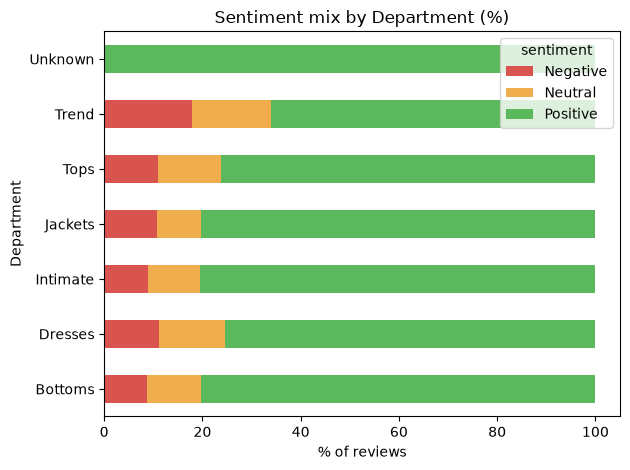

In [30]:

# (a) sentiment mix within each department -> where do negatives concentrate?
dep_sent = (df.groupby('department_name')['sentiment']
              .value_counts(normalize=True).unstack().fillna(0)*100)
dep_sent = dep_sent[['Negative', 'Neutral', 'Positive']]
dep_sent.plot(kind='barh', stacked=True,
              color=['#d9534f', '#f0ad4e', '#5cb85c'])
plt.title('Sentiment mix by Department (%)')
plt.xlabel('% of reviews')
plt.ylabel('Department')
plt.tight_layout()
plt.show()



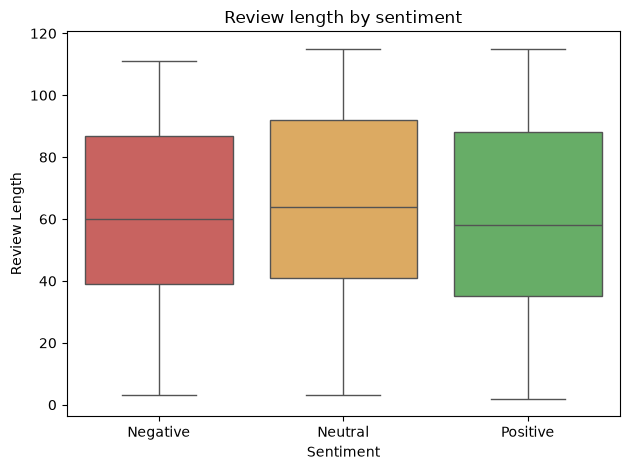

In [31]:
# (b) review_length vs sentiment -> are unhappy customers more verbose?
sns.boxplot(x='sentiment', y='review_length', data=df,
            order=['Negative', 'Neutral', 'Positive'], hue='sentiment',
            palette={'Negative':'#d9534f','Neutral':'#f0ad4e','Positive':'#5cb85c'},
            legend=False)

plt.title('Review length by sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Review Length')
plt.tight_layout()
plt.show()




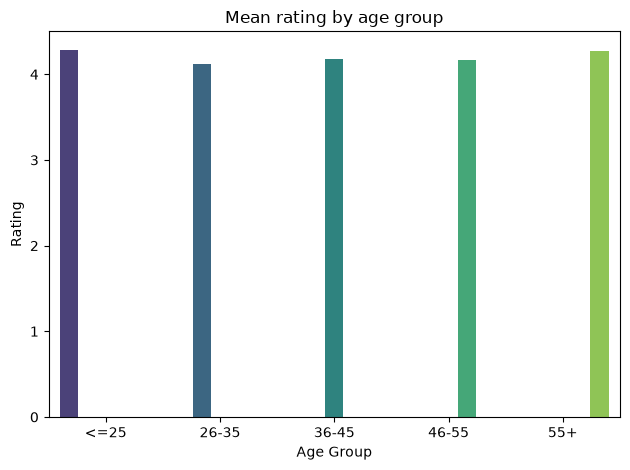

In [32]:
# (c) mean rating by age_group -> satisfaction across demographics
age_rating = df.groupby('age_group', observed=True)['rating'].mean()
sns.barplot(x=age_rating.index, y=age_rating.values, hue=age_rating.index,
            palette='viridis', legend=False)

plt.title('Mean rating by age group')
plt.xlabel('Age Group')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()


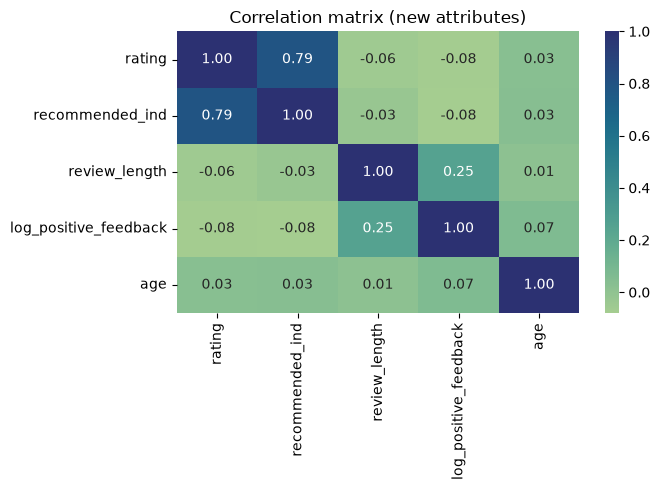

In [33]:
# Correlation incl. engineered numeric features
corr = df[['rating', 'recommended_ind', 'review_length',
            'log_positive_feedback', 'age']].corr()

# Heatmap of the correlation matrix
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='crest', fmt='.2f')
plt.title('Correlation matrix (new attributes)');
plt.tight_layout()
plt.show()

### 4.2 Detailed EDA visualizations with insights

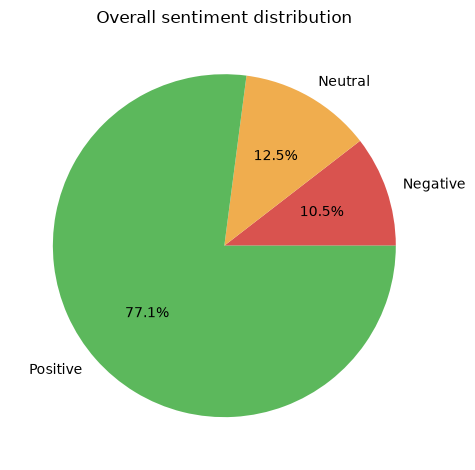

In [34]:
# (a) overall sentiment split -> scale of the negative-feedback workload
sent_counts = df['sentiment'].value_counts()[['Negative', 'Neutral', 'Positive']]
plt.pie(sent_counts, labels=sent_counts.index, autopct='%1.1f%%',
            colors=['#d9534f', '#f0ad4e', '#5cb85c'])
plt.title('Overall sentiment distribution')
plt.tight_layout()
plt.show()

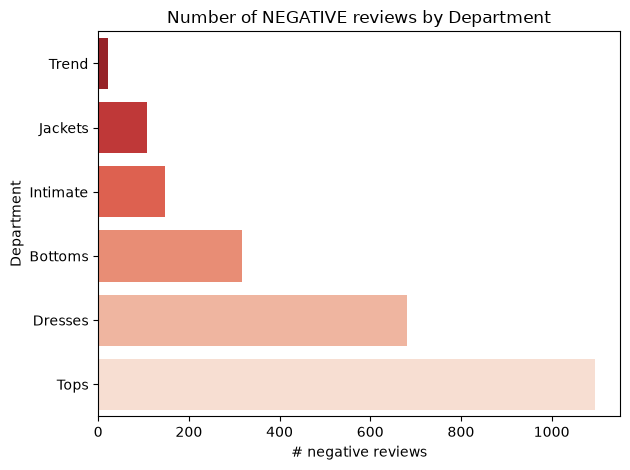

Negative reviews: 2,370 (10.5% of total)


In [35]:
# (b) count of NEGATIVE reviews by department -> where to prioritise response teams
neg_by_dep = (df[df['sentiment'] == 'Negative']['department_name']
              .value_counts().sort_values())
sns.barplot(x=neg_by_dep.values, y=neg_by_dep.index, hue=neg_by_dep.index,
            palette='Reds_r', legend=False)
plt.title('Number of NEGATIVE reviews by Department')
plt.xlabel('# negative reviews')
plt.ylabel('Department')
plt.tight_layout()
plt.show()

print(f"Negative reviews: {(df['sentiment']=='Negative').sum():,} "
      f"({(df['sentiment']=='Negative').mean()*100:.1f}% of total)")

### 4.3 Justification of insights & inference

- **~77% of reviews are Positive** and only a minority Negative → the operational challenge is
  *finding the needles* (urgent complaints) in a largely happy haystack — exactly what the
  GenAI + urgency-detection pipeline is designed for.
- **Negative reviews cluster in the high-volume departments (Tops, Dresses)** simply because they
  carry the most traffic → response staffing should be **proportional to negative volume**, not
  total volume.
- **Unhappy customers write longer reviews** (higher median `review_length` for Negative) → review
  length is a cheap **proxy feature for effort/urgency** and can help rank the response queue.
- **Rating correlates strongly with recommendation but weakly with age/feedback count** → the
  *structured* columns alone can't predict satisfaction; the **text content is essential**,
  justifying the prompt-engineering approach.


## Save the cleaned & enriched dataset

In [36]:
# Persist the processed dataframe for the next milestones
df.to_csv('cleaned_reviews.csv', index=False)
print('Saved cleaned_reviews.csv | shape:', df.shape)
print('Columns:', list(df.columns))

Saved cleaned_reviews.csv | shape: (22640, 13)
Columns: ['age', 'title', 'review_text', 'rating', 'recommended_ind', 'positive_feedback_count', 'division_name', 'department_name', 'class_name', 'sentiment', 'review_length', 'log_positive_feedback', 'age_group']
